In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [10]:
df = pd.read_csv("ADANIENT.csv")

df.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,ADANIENT.NS,ADANIENT.NS,ADANIENT.NS,ADANIENT.NS,ADANIENT.NS
1,Date,NaN,NaN,NaN,NaN,NaN
2,2026-02-04,2228.199951171875,2246.0,2189.199951171875,2220.0,2051918
3,2026-02-05,2236.60009765625,2243.699951171875,2210.0,2232.0,992382
4,2026-02-06,2226.39990234375,2238.0,2200.39990234375,2226.10009765625,933650


In [6]:
df.describe()

,Price,Close,High,Low,Open,Volume
count,22,21,21,21,21,21
unique,22,21,21,21,20,21
top,Ticker,ADANIENT.NS,ADANIENT.NS,ADANIENT.NS,2210.0,ADANIENT.NS
freq,1,1,1,1,2,1


In [7]:
df.columns

Index(['Price', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   22 non-null     object
 1   Close   21 non-null     object
 2   High    21 non-null     object
 3   Low     21 non-null     object
 4   Open    21 non-null     object
 5   Volume  21 non-null     object
dtypes: object(6)
memory usage: 1.2+ KB


In [13]:
df.isnull().sum()

Price     0
Close     1
High      1
Low       1
Open      1
Volume    1
dtype: int64

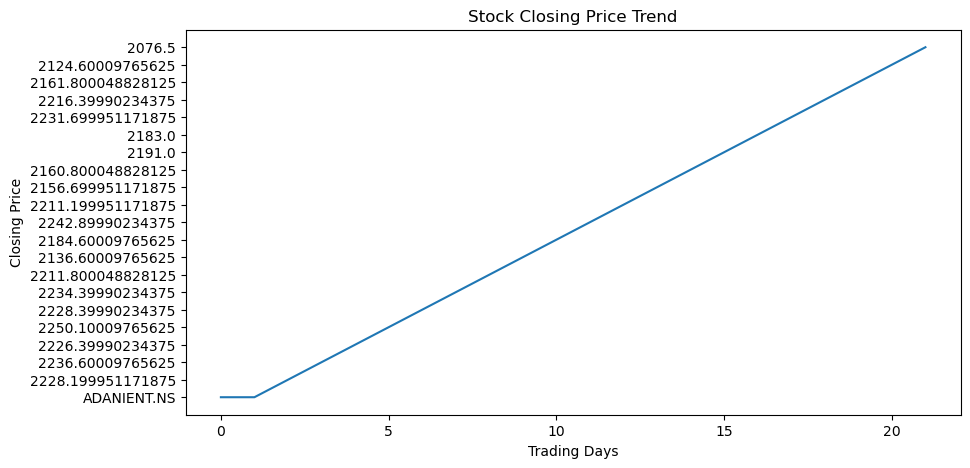

In [15]:
plt.figure(figsize=(10,5))
plt.plot(df['Close'])
plt.title("Stock Closing Price Trend")
plt.xlabel("Trading Days")
plt.ylabel("Closing Price")
plt.show()

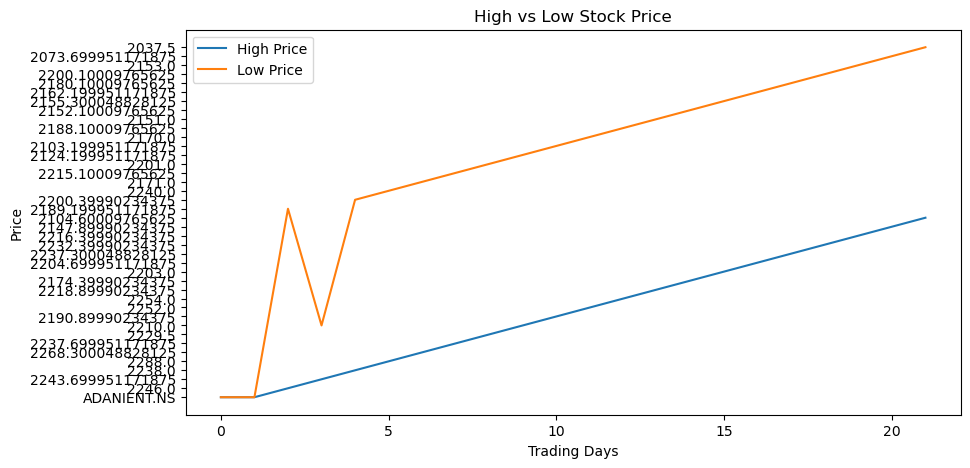

In [16]:
plt.figure(figsize=(10,5))
plt.plot(df['High'], label='High Price')
plt.plot(df['Low'], label='Low Price')
plt.title("High vs Low Stock Price")
plt.xlabel("Trading Days")
plt.ylabel("Price")
plt.legend()
plt.show()

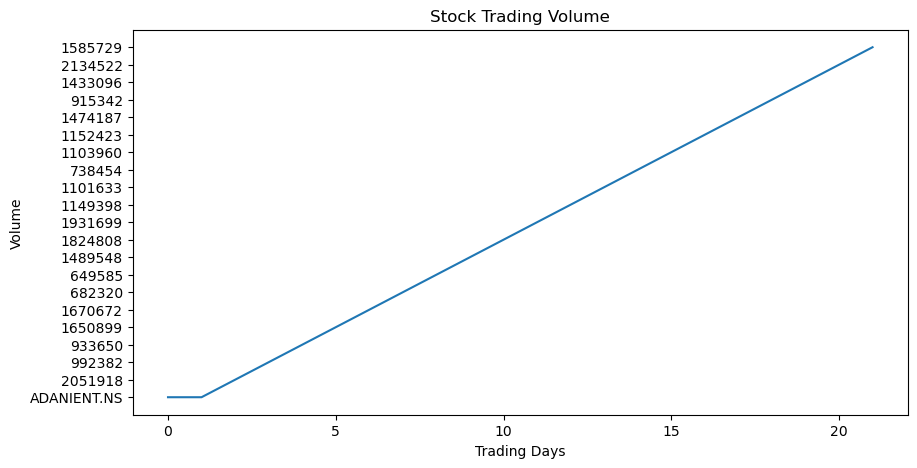

In [17]:
plt.figure(figsize=(10,5))
plt.plot(df['Volume'])
plt.title("Stock Trading Volume")
plt.xlabel("Trading Days")
plt.ylabel("Volume")
plt.show()

In [19]:
df.dtypes

Price     object
Close     object
High      object
Low       object
Open      object
Volume    object
dtype: object

In [20]:
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
df['Open'] = pd.to_numeric(df['Open'], errors='coerce')
df['High'] = pd.to_numeric(df['High'], errors='coerce')
df['Low'] = pd.to_numeric(df['Low'], errors='coerce')
df['Volume'] = pd.to_numeric(df['Volume'], errors='coerce')

In [21]:
df = df.dropna()

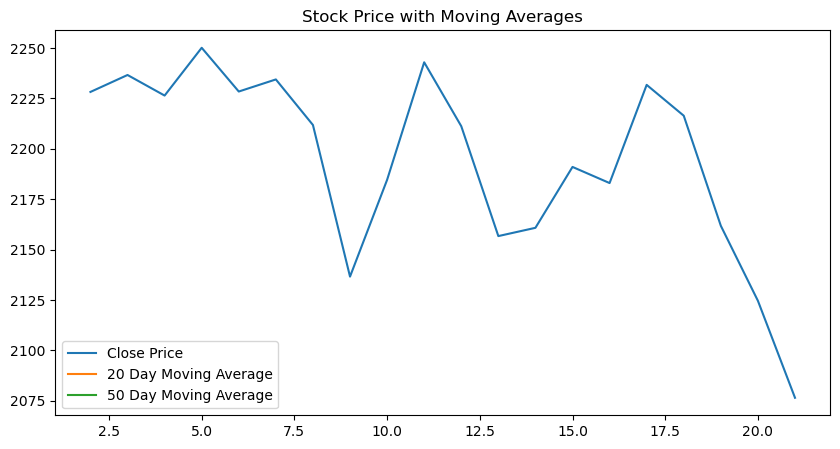

In [23]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(df['Close'], label='Close Price')
plt.plot(df['MA20'], label='20 Day Moving Average')
plt.plot(df['MA50'], label='50 Day Moving Average')
plt.legend()
plt.title("Stock Price with Moving Averages")
plt.show()

In [26]:
df.columns = df.columns.str.strip()

In [27]:
df.dtypes

Price            object
Close           float64
High            float64
Low             float64
Open            float64
Volume          float64
MA20            float64
MA50            float64
Daily_Return    float64
dtype: object

In [29]:
df['Daily_Return'] = df['Close'].pct_change()

df.head()

C:\Users\Media Computers\AppData\Local\Temp\ipykernel_10132\298894717.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Daily_Return'] = df['Close'].pct_change()


,Price,Close,High,Low,Open,Volume,MA20,MA50,Daily_Return
2,2026-02-04,2228.199951,2246.000000,2189.199951,2220.000000,2051918.0,NaN,NaN,NaN
3,2026-02-05,2236.600098,2243.699951,2210.000000,2232.000000,992382.0,NaN,NaN,0.003770
4,2026-02-06,2226.399902,2238.000000,2200.399902,2226.100098,933650.0,NaN,NaN,-0.004561
5,2026-02-09,2250.100098,2288.000000,2240.000000,2250.000000,1650899.0,NaN,NaN,0.010645
6,2026-02-10,2228.399902,2268.300049,2171.000000,2259.000000,1670672.0,NaN,NaN,-0.009644


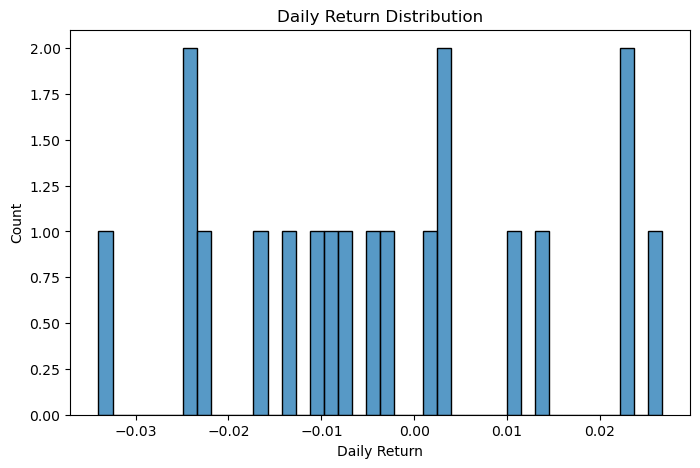

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sns.histplot(df['Daily_Return'], bins=40)
plt.title("Daily Return Distribution")
plt.xlabel("Daily Return")
plt.show()

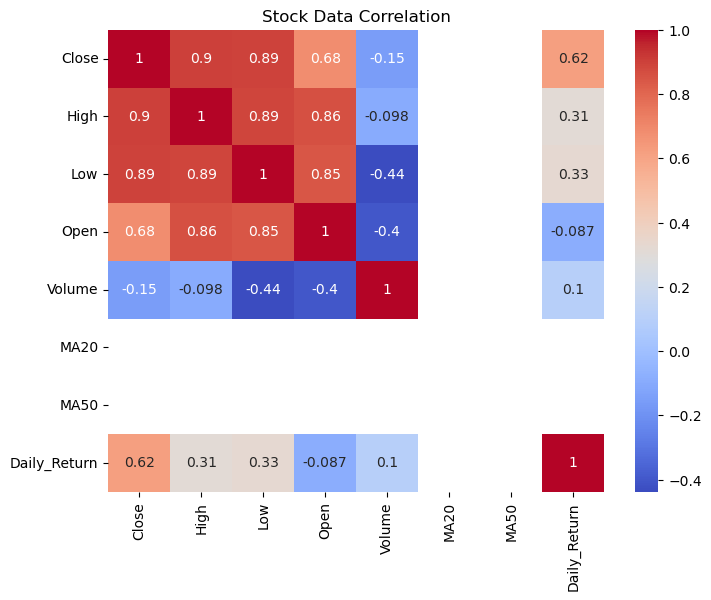

In [32]:
plt.figure(figsize=(8,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Stock Data Correlation")
plt.show()

Key Findings:

-Stock price fluctuates across trading days.
-High and low prices show market volatility.
-Moving averages help identify price trends.
-Daily return distribution shows stock volatility patterns.